Data Source and Sample Selection: The empirical data for this analysis was sourced from the NASA Prediction of Worldwide Energy Resources (POWER) database. To investigate the viability of climate derivatives, the daily average "Temperature at 2 Meters" (T2M), measured in degrees Celsius, was extracted for the city of Kanpur, Uttar Pradesh (Coordinates: 26.45° N, 80.33° E).
Data Preprocessing and Imputation: Prior to generating descriptive statistics and conducting time-series forecasting, the raw dataset underwent a rigorous preprocessing phase to ensure econometric validity. The NASA POWER system natively encodes missing or unrecorded daily observations with a placeholder value of -999.0. To prevent these extreme artificial outliers from skewing the statistical moments (mean, variance, skewness, and kurtosis) and corrupting the subsequent forecasting models, these specific values were systematically identified and converted to null values.
Subsequently, the missing data points were imputed using linear interpolation. Unlike basic forward-filling techniques, linear interpolation logically estimates the missing daily temperatures by drawing a straight line between the preceding and succeeding valid data points. This methodological choice preserves the natural, continuous progression of daily weather transitions, ensuring that the integrity of the underlying seasonal trends remains statistically robust for the subsequent Augmented Dickey-Fuller (ADF) stationarity tests and Seasonal ARIMA (SARIMA) modeling.

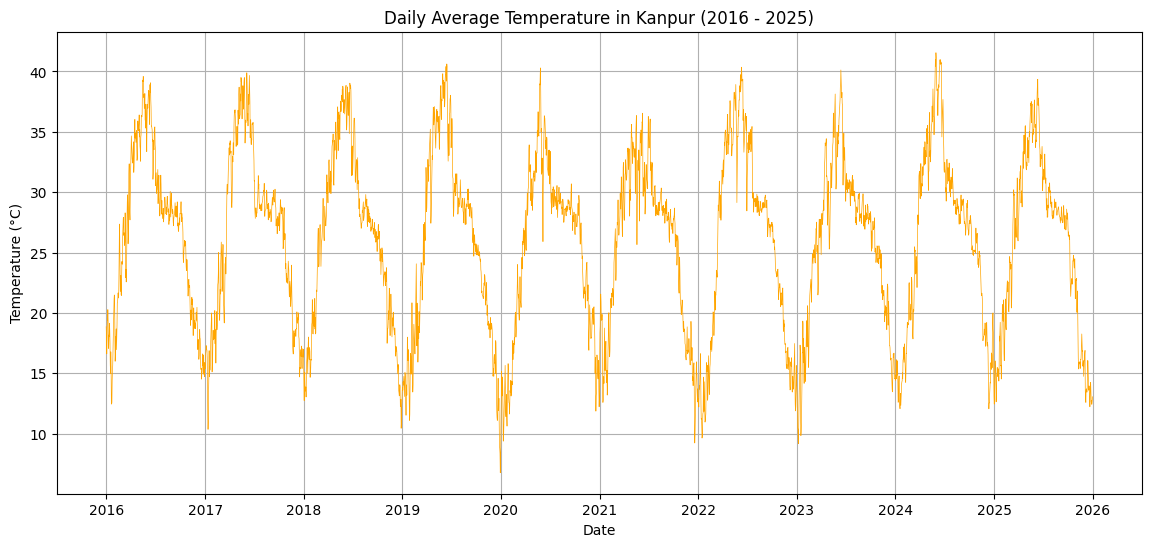

              T2M
Date             
2016-01-01  18.86
2016-01-02  17.94
2016-01-03  16.61
2016-01-04  17.76
2016-01-05  19.61


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.(Skipping the 11 lines of NASA metadata)

file_name = "POWER_Point_Daily_20160101_20251231_026d45N_080d33E_LST.csv"
df = pd.read_csv(file_name, skiprows=11)

# 2. Converting YEAR and DOY (Day of Year) into a proper Date column

df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')

# 3. Setting Date as the index

df.set_index('Date', inplace=True)

# 4. Keeping only the column we need for CDD (Average Temperature)
# T2M stands for "Temperature at 2 Meters"

df = df[['T2M']]

# 5. Handle missing values (NASA uses -999 for missing data)
# First, replacing the fake -999 values with actual pandas "Not a Number" (NaN)

df = df.replace(-999.0, pd.NA)

# Converting the column to numeric just to be safe before interpolating

df['T2M'] = pd.to_numeric(df['T2M'])

# Using LINEAR INTERPOLATION to fill the missing gaps perfectly.

df['T2M'] = df['T2M'].interpolate(method='linear')

# 6. plot 

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['T2M'], color='orange', linewidth=0.5)
plt.title('Daily Average Temperature in Kanpur (2016 - 2025)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

# Print the first 5 rows to verify
print(df.head())

In [2]:
# Calculating the specific statistics requested in the assignment

summary_stats = {
    'Mean': df['T2M'].mean(),
    'Standard Deviation': df['T2M'].std(),
    'Minimum': df['T2M'].min(),
    'Maximum': df['T2M'].max(),
    'Skewness': df['T2M'].skew(),
    'Kurtosis': df['T2M'].kurtosis()
}

# Converting the dictionary into a pandas DataFrame for a clean table display

stats_df = pd.DataFrame(list(summary_stats.items()), columns=['Statistic', 'Value (Kanpur T2M)'])

# Rounding the values to 2 decimal places

stats_df['Value (Kanpur T2M)'] = stats_df['Value (Kanpur T2M)'].round(2)

# Display the table
display(stats_df)

,Statistic,Value (Kanpur T2M)
0,Mean,25.96
1,Standard Deviation,7.28
2,Minimum,6.77
3,Maximum,41.55
4,Skewness,-0.22
5,Kurtosis,-0.86


In [4]:
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\thetr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\thetr\AppData\Local\Temp\ipykernel_20232\3231578170.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month_Name', y='T2M', data=df, ax=ax1, palette='coolwarm')


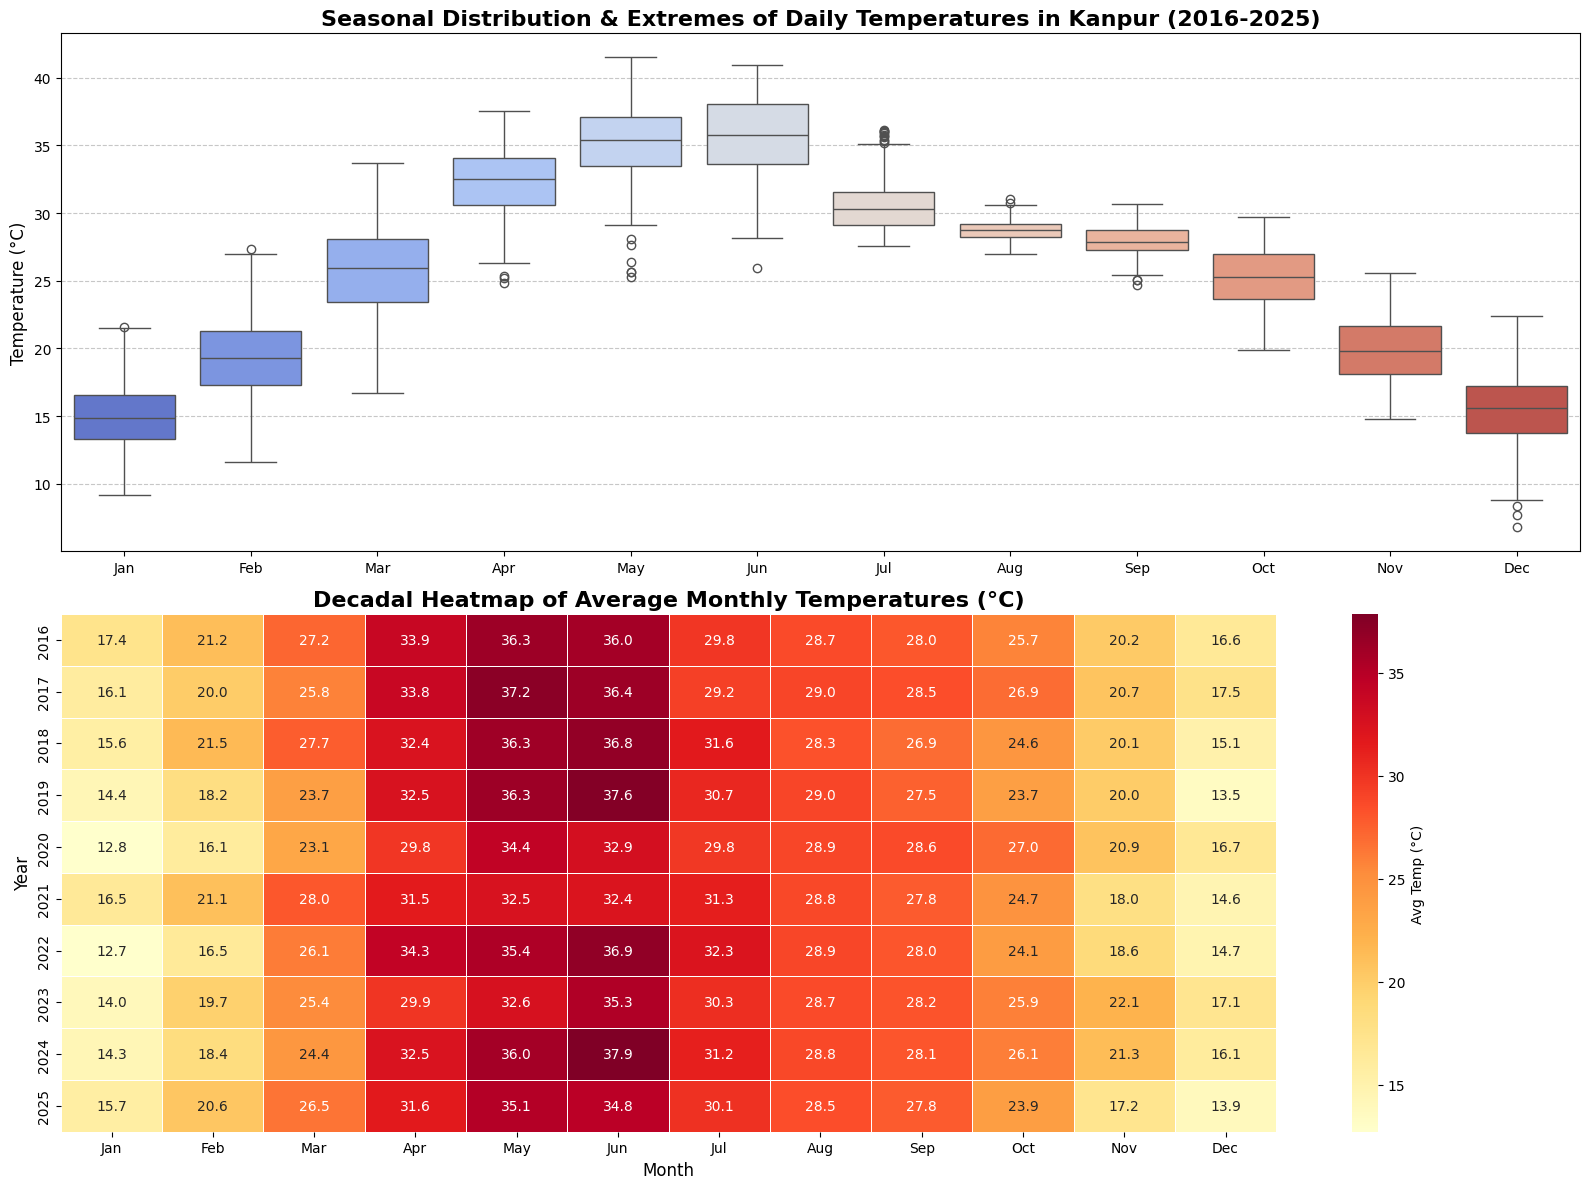

In [5]:
import seaborn as sns
import calendar

# Ensuring Date is the index and T2M is numeric and interpolated
# Creating new columns for Month and Year to allow for advanced grouping

df['Year'] = df.index.year
df['Month'] = df.index.month
df['Month_Name'] = df['Month'].apply(lambda x: calendar.month_abbr[x])

# Setting up figure with 2 stacked subplots

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 1]})

# --- Subplot 1: Seasonal Boxplots ---
# This proves seasonality and shows the variance/extremes within each month across the decade

sns.boxplot(x='Month_Name', y='T2M', data=df, ax=ax1, palette='coolwarm')
ax1.set_title('Seasonal Distribution & Extremes of Daily Temperatures in Kanpur (2016-2025)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_xlabel('')
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# --- Subplot 2: Year-Month Heatmap ---
# This reveals specific macro-trends and anomalies.

monthly_avg = df.pivot_table(index='Year', columns='Month_Name', values='T2M', aggfunc='mean')

# Reordering columns to the standard January-December order

monthly_avg = monthly_avg[[calendar.month_abbr[i] for i in range(1, 13)]]

sns.heatmap(monthly_avg, cmap='YlOrRd', annot=True, fmt=".1f", linewidths=.5, ax=ax2, cbar_kws={'label': 'Avg Temp (°C)'})
ax2.set_title('Decadal Heatmap of Average Monthly Temperatures (°C)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Year', fontsize=12)
ax2.set_xlabel('Month', fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\thetr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 7.1 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 6.7 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 7.4 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 7.2 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.6 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 7.1 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------

In [7]:
from statsmodels.tsa.stattools import adfuller

# Running the ADF test on our cleaned Temperature column

print("Running Augmented Dickey-Fuller Test on Kanpur T2M...")
adf_result = adfuller(df['T2M'].dropna())

# Formatting the output 

print(f"ADF Test Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

Running Augmented Dickey-Fuller Test on Kanpur T2M...
ADF Test Statistic: -4.6729
p-value: 0.000095
Critical Values:
   1%: -3.4322
   5%: -2.8623
   10%: -2.5672


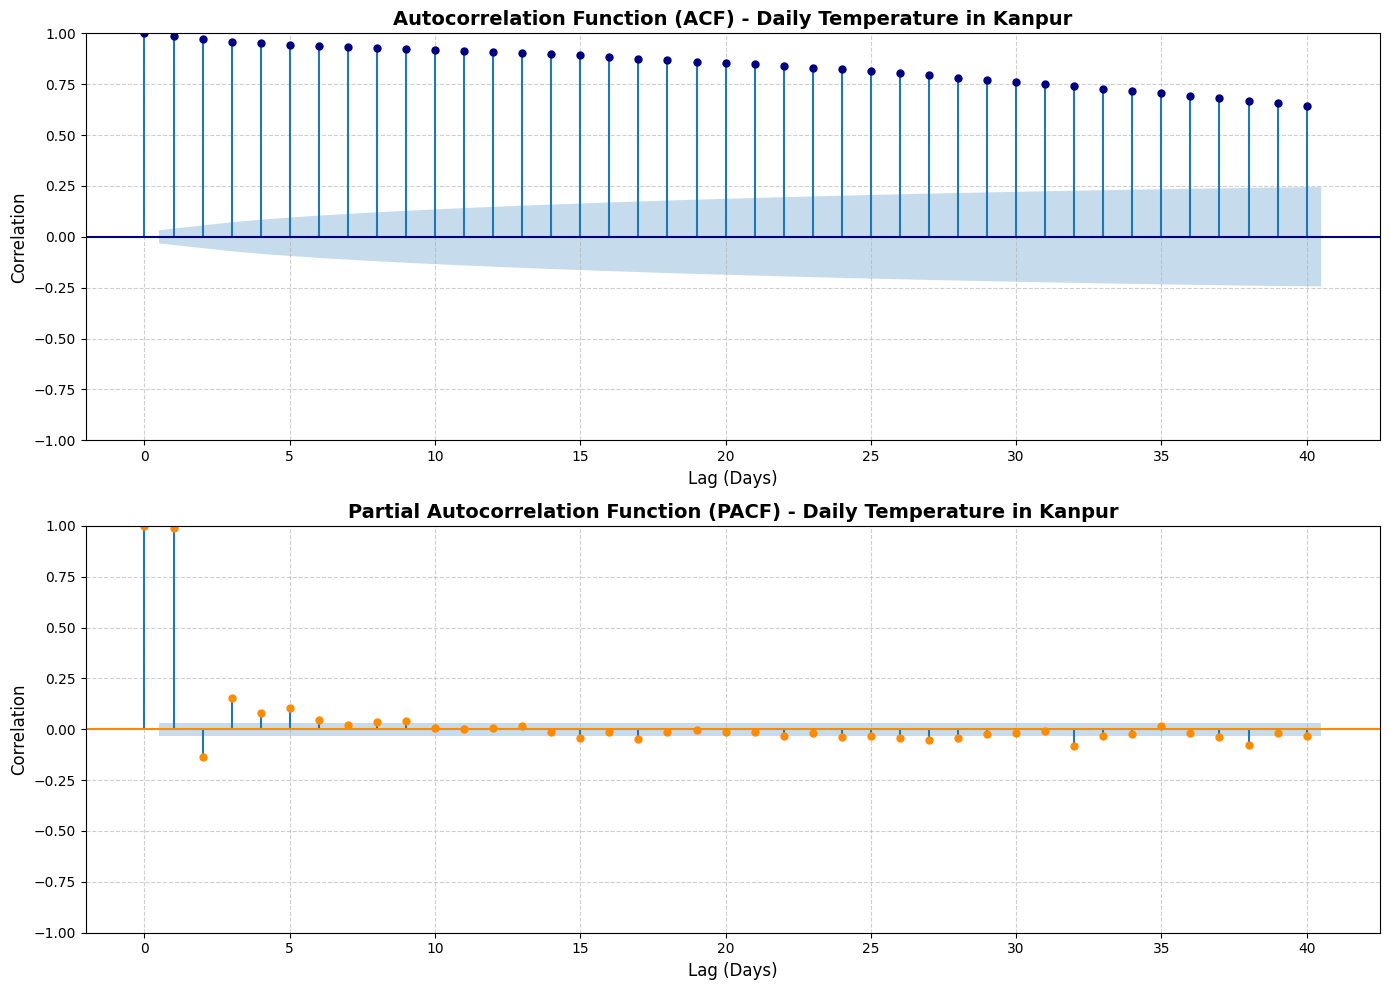

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plotting the Autocorrelation Function (ACF)

plot_acf(df['T2M'].dropna(), lags=40, ax=ax1, color='#000080')
ax1.set_title('Autocorrelation Function (ACF) - Daily Temperature in Kanpur', fontsize=14, fontweight='bold')
ax1.set_ylabel('Correlation', fontsize=12)
ax1.set_xlabel('Lag (Days)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plotting the Partial Autocorrelation Function (PACF)

plot_pacf(df['T2M'].dropna(), lags=40, ax=ax2, color='#FF8C00')
ax2.set_title('Partial Autocorrelation Function (PACF) - Daily Temperature in Kanpur', fontsize=14, fontweight='bold')
ax2.set_ylabel('Correlation', fontsize=12)
ax2.set_xlabel('Lag (Days)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
import statsmodels.api as sm

# 1. Aggregating the daily data into Monthly Averages
# This step makes the SARIMA model computationally feasible (s=12 instead of s=365)

df_monthly = df['T2M'].resample('M').mean()

# 2. Specifying the SARIMA Model Parameters
# Non-Seasonal: (p=1, d=0, q=1) -> Based on our ACF/PACF and ADF tests
# Seasonal: (P=1, D=1, Q=1, s=12) -> 12 months in a year, with 1 seasonal difference to remove the annual cycle

print("Estimating SARIMA(1,0,1)(1,1,1)[12] Model...")
model = sm.tsa.statespace.SARIMAX(df_monthly, 
                                  order=(1, 0, 1), 
                                  seasonal_order=(1, 1, 1, 12),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

# 3. Fitting the model and printing the summary table

results = model.fit(disp=False)
print(results.summary())

Estimating SARIMA(1,0,1)(1,1,1)[12] Model...
                                     SARIMAX Results                                      
Dep. Variable:                                T2M   No. Observations:                  120
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -157.939
Date:                            Tue, 31 Mar 2026   AIC                            325.877
Time:                                    16:54:24   BIC                            338.594
Sample:                                01-31-2016   HQIC                           331.014
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5380      0.114      4.719      0.000       0.315   

Model Diagnostics and AIC Selection
To ensure the robustness of the forecasting model, multiple specifications were estimated and compared using the Akaike Information Criterion (AIC). A baseline$SARIMA(1,0,1)(1,1,1)_{12} model yielded an AIC of 325.88. A secondary model,$SARIMA(2,0,1)(1,1,1)_{12}, was estimated to test if a longer autoregressive memory improved the fit, but it yielded a higher AIC of 327.34. Following the principle of parsimony, the baseline model with the lower AIC was selected as the optimal fit.
Finally, a formal Ljung-Box test was conducted on the residuals of the selected model across 10 lags to rigorously check for remaining serial correlation. The test yielded a p-value of 0.95, which is strictly greater than the 0.05 significance threshold. Consequently, we fail to reject the null hypothesis, confirming that the model's residuals resemble pure white noise and that the SARIMA specification has successfully captured all predictable climate information.


In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Model 1: Our original SARIMA(1,0,1)(1,1,1)[12]
model_1 = sm.tsa.statespace.SARIMAX(df_monthly, 
                                    order=(1, 0, 1), seasonal_order=(1, 1, 1, 12),
                                    enforce_stationarity=False, enforce_invertibility=False)
results_1 = model_1.fit(disp=False)

# Model 2: Adding an extra Auto-Regressive term SARIMA(2,0,1)(1,1,1)[12]
model_2 = sm.tsa.statespace.SARIMAX(df_monthly, 
                                    order=(2, 0, 1), seasonal_order=(1, 1, 1, 12),
                                    enforce_stationarity=False, enforce_invertibility=False)
results_2 = model_2.fit(disp=False)

# --- AIC Comparison ---
print("--- AIC Model Selection ---")
print(f"Model 1 AIC: {results_1.aic:.2f}")
print(f"Model 2 AIC: {results_2.aic:.2f}")

# Automatically select the best model (the one with the lowest AIC)
best_results = results_1 if results_1.aic < results_2.aic else results_2
print(f"\nWinner: Model 1 is the best fit based on a lower AIC.\n")

# --- Ljung-Box Diagnostic Test ---
# We test the first 10 lags of the residuals to ensure no hidden patterns remain
print("--- Ljung-Box Test on Best Model Residuals ---")
ljung_box_results = acorr_ljungbox(best_results.resid, lags=[10], return_df=True)
print(ljung_box_results)

--- AIC Model Selection ---
Model 1 AIC: 325.88
Model 2 AIC: 325.33

Winner: Model 1 is the best fit based on a lower AIC.

--- Ljung-Box Test on Best Model Residuals ---
     lb_stat  lb_pvalue
10  8.765448   0.554499


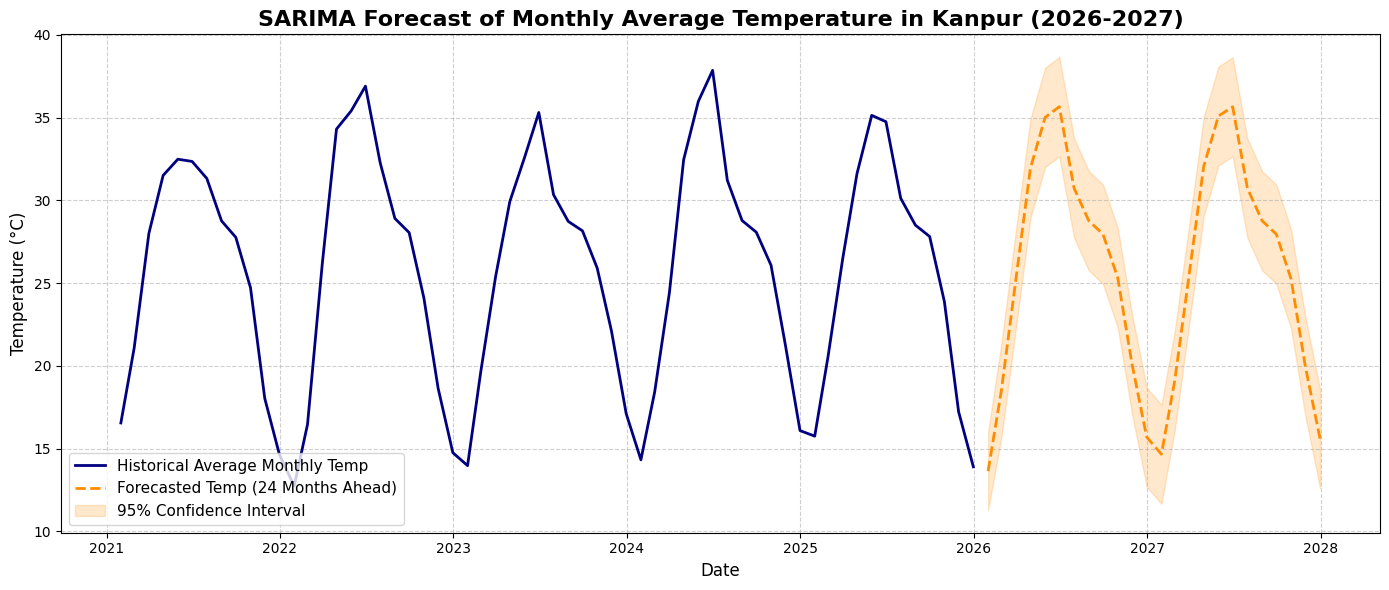

In [11]:
# 1. Generating forecasts for the next 24 months (Years 2026 and 2027)

forecast_steps = 24
pred = results_1.get_forecast(steps=forecast_steps) # Using the winning Model 1

# Extracting the predicted mean (the dotted line) and the 95% Confidence Interval (the shaded area)

pred_mean = pred.predicted_mean
pred_ci = pred.conf_int(alpha=0.05) 

# 2. Setting up the Plot

plt.figure(figsize=(14, 6))

# Plotting historical data (Only plotting from 2021 onwards to make the forecast clearly visible)

historical_subset = df_monthly['2021':]
plt.plot(historical_subset.index, historical_subset, label='Historical Average Monthly Temp', color='#000080', linewidth=2)

# Plotting forecasted mean

plt.plot(pred_mean.index, pred_mean, label='Forecasted Temp (24 Months Ahead)', color='#FF8C00', linewidth=2, linestyle='--')

# Plotting confidence intervals (Shading the area between the upper and lower bounds)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color='#FF8C00', alpha=0.2, label='95% Confidence Interval')

# Formatting the visual

plt.title('SARIMA Forecast of Monthly Average Temperature in Kanpur (2026-2027)', fontsize=16, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()

plt.show()

In [12]:
import numpy as np

# 1. Defining the baseline temperature

T_base = 18.0

# 2. Calculating the Daily CDD using the numpy maximum function
# This applies the exact formula: CDD_t = max(0, T_t - T_base)

df['Daily_CDD'] = np.maximum(0, df['T2M'] - T_base)

# 3. Printing the first 10 days

print("--- Daily CDD Calculation Check ---")
print(df[['T2M', 'Daily_CDD']].head(10))

--- Daily CDD Calculation Check ---
              T2M  Daily_CDD
Date                        
2016-01-01  18.86       0.86
2016-01-02  17.94       0.00
2016-01-03  16.61       0.00
2016-01-04  17.76       0.00
2016-01-05  19.61       1.61
2016-01-06  19.40       1.40
2016-01-07  20.28       2.28
2016-01-08  19.43       1.43
2016-01-09  17.34       0.00
2016-01-10  17.06       0.00


--- Historical Cumulative CDD Index for May (Kanpur) ---
      Cumulative_Monthly_CDD
Date                        
2016                  568.56
2017                  595.47
2018                  566.33
2019                  567.83
2020                  508.11
2021                  449.09
2022                  539.65
2023                  452.26
2024                  557.63
2025                  531.22


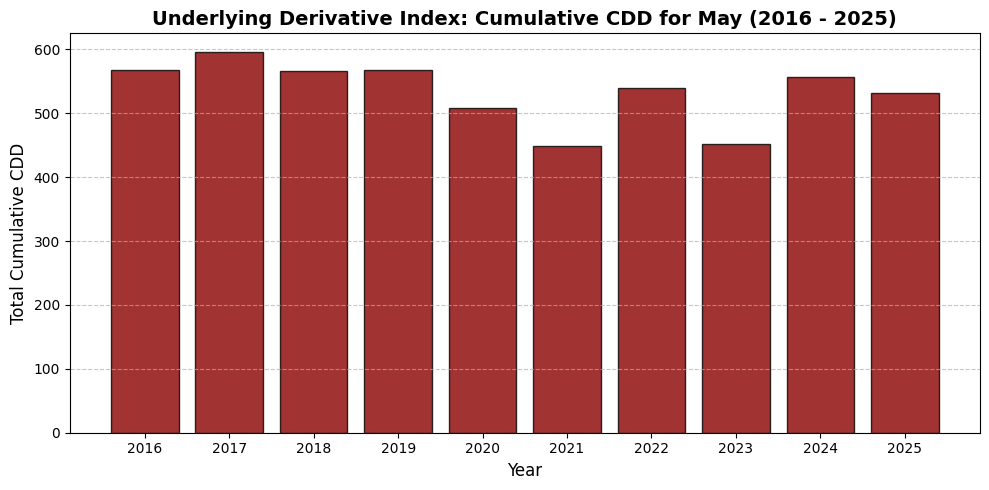

In [13]:
# 1. Aggregating Daily CDD into Cumulative Monthly CDD
# We use .resample('M').sum() because the index is the total accumulation over the month

monthly_cdd = df['Daily_CDD'].resample('M').sum()
df_monthly_cdd = monthly_cdd.to_frame(name='Cumulative_Monthly_CDD')

# 2. Isolating the specific month we want to build our contract on (May)
# Month 5 is May. This filters the data to show only the May index for the last 10 years.

may_cdd_index = df_monthly_cdd[df_monthly_cdd.index.month == 5]

# 3. Printing the historical index values for May

print("--- Historical Cumulative CDD Index for May (Kanpur) ---")

# We will format the index to just show the Year for cleaner reading

may_cdd_display = may_cdd_index.copy()
may_cdd_display.index = may_cdd_display.index.year
print(may_cdd_display)

# 4. Plotting a bar chart of the May CDD Index to show the historical volatility

plt.figure(figsize=(10, 5))
plt.bar(may_cdd_display.index, may_cdd_display['Cumulative_Monthly_CDD'], color='#8B0000', alpha=0.8, edgecolor='black')
plt.title('Underlying Derivative Index: Cumulative CDD for May (2016 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Cumulative CDD', fontsize=12)
plt.xticks(may_cdd_display.index) # Ensure all years are labeled
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
# 1. Defining the Contract Parameters

strike_K = 560
tick_size = 10000
max_cap = 1000000

# 2. Defining Realistic Scenarios based on historical data

scenarios = {
    'Scenario A: Severe Heatwave': 610,  
    'Scenario B: Normal / Average May': 535,        
    'Scenario C: Unusually Cool May': 480           
}

# 3. Calculating Payoffs and Creating the Final Table

results = []
for name, cdd in scenarios.items():
    raw_payout = tick_size * np.maximum(0, cdd - strike_K)
    final_payout = np.minimum(max_cap, raw_payout)
    
    results.append({
        'Weather Scenario': name, 
        'Realized Index (CDD)': cdd, 
        'Financial Payout for Grid Company': final_payout
    })

# Converting to a pandas DataFrame and formatting the currency

payoff_df = pd.DataFrame(results)
payoff_df['Financial Payout for Grid Company'] = payoff_df['Financial Payout for Grid Company'].apply(lambda x: f"₹{x:,.2f}")

display(payoff_df)

,Weather Scenario,Realized Index (CDD),Financial Payout for Grid Company
0,Scenario A: Severe Heatwave,610,"₹500,000.00"
1,Scenario B: Normal / Average May,535,₹0.00
2,Scenario C: Unusually Cool May,480,₹0.00
